
# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
!pip install category_encoders
import pandas as pd
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 3.2 MB/s eta 0:00:00


In [2]:
from google.colab import files
file = files.upload()

Saving customer_booking.csv to customer_booking.csv


In [3]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [5]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [6]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)


In [7]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [8]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [9]:
print(df['booking_complete'].value_counts())
print(f"\nCompletion rate: {df['booking_complete'].mean()*100:.1f}%")
print(f"\nMissing values are:\n{df.isnull().sum()}")

booking_complete
0    42522
1     7478
Name: count, dtype: int64

Completion rate: 15.0%

Missing values are:
num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64


In [10]:
categorical_cols=["sales_channel", "trip_type", "route", "booking_origin"]
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")


sales_channel: 2 unique values

trip_type: 3 unique values

route: 799 unique values

booking_origin: 104 unique values


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_passengers,50000.0,1.591240,1.020165,1.00,1.00,1.00,2.00,9.0
purchase_lead,50000.0,84.940480,90.451378,0.00,21.00,51.00,115.00,867.0
length_of_stay,50000.0,23.044560,33.887670,0.00,5.00,17.00,28.00,778.0
flight_hour,50000.0,9.066340,5.412660,0.00,5.00,9.00,13.00,23.0
flight_day,50000.0,3.814420,1.992792,1.00,2.00,4.00,5.00,7.0
wants_extra_baggage,50000.0,0.668780,0.470657,0.00,0.00,1.00,1.00,1.0
wants_preferred_seat,50000.0,0.296960,0.456923,0.00,0.00,0.00,1.00,1.0
wants_in_flight_meals,50000.0,0.427140,0.494668,0.00,0.00,0.00,1.00,1.0
flight_duration,50000.0,7.277561,1.496863,4.67,5.62,7.57,8.83,9.5
booking_complete,50000.0,0.149560,0.356643,0.00,0.00,0.00,0.00,1.0


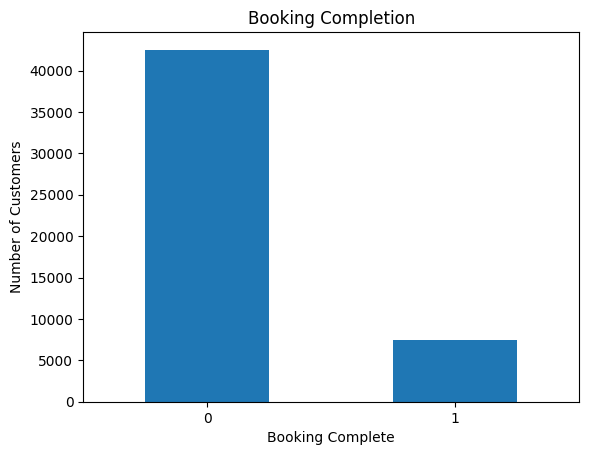

In [12]:
df["booking_complete"].value_counts().plot(kind="bar")

plt.title("Booking Completion")
plt.xlabel("Booking Complete")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [13]:
# Feature 1: Is the flight on a weekend?
df["is_weekend_flight"] = df["flight_day"].isin([6, 7]).astype(int)

# Feature 2: Is the flight in the early morning (before 08:00)?
df['is_early_morning'] = (df['flight_hour'] < 8).astype(int)

# Feature 3: Did the customer book within 30 days of departure?
df['books_within_30_days'] = (df['purchase_lead'] <= 30).astype(int)

# Feature 4: Is the stay longer than 14 nights?
df['long_stay'] = (df['length_of_stay'] > 14).astype(int)

# Feature 5: Total number of extras selected (baggage + seat + meals)
df['total_extras'] = (df['wants_extra_baggage'] +
                      df['wants_preferred_seat'] +
                      df['wants_in_flight_meals'])

print('=== NEW FEATURES SUMMARY ===')
new_features = ['is_weekend_flight','is_early_morning','books_within_30_days','long_stay','total_extras']
for f in new_features:
    print(f'\n{f}:')
    print(df[f].value_counts().sort_index().to_string())

=== NEW FEATURES SUMMARY ===

is_weekend_flight:
is_weekend_flight
0    37634
1    12366

is_early_morning:
is_early_morning
0    29205
1    20795

books_within_30_days:
books_within_30_days
0    32861
1    17139

long_stay:
long_stay
0    24673
1    25327

total_extras:
total_extras
0    10455
1    18216
2    12559
3     8770


In [14]:
features = [
    "is_weekend_flight",
    "is_early_morning",
    "books_within_30_days",
    "long_stay",
    "total_extras"
]

for feature in features:
    print(f"\n--- {feature} ---")
    print(
        df.groupby(feature)["booking_complete"]
          .mean()
          .mul(100)
          .round(2)
    )


--- is_weekend_flight ---
is_weekend_flight
0    15.12
1    14.46
Name: booking_complete, dtype: float64

--- is_early_morning ---
is_early_morning
0    15.26
1    14.53
Name: booking_complete, dtype: float64

--- books_within_30_days ---
books_within_30_days
0    14.18
1    16.45
Name: booking_complete, dtype: float64

--- long_stay ---
long_stay
0    19.17
1    10.85
Name: booking_complete, dtype: float64

--- total_extras ---
total_extras
0    10.67
1    14.96
2    15.97
3    18.60
Name: booking_complete, dtype: float64


In [15]:
df.shape

(50000, 19)

In [16]:
feature_cols = [
    "num_passengers",
    "sales_channel",
    "trip_type",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_day",
    "route",
    "booking_origin",
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals",
    "flight_duration",
    "is_weekend_flight",
    "is_early_morning",
    "books_within_30_days",
    "long_stay",
    "total_extras"
]

X = df[feature_cols]
y = df["booking_complete"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 18)
y shape: (50000,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (40000, 18)
X_test : (10000, 18)
y_train: (40000,)
y_test : (10000,)


In [20]:
target_cols = ["route", "booking_origin"]
onehot_cols = ["sales_channel", "trip_type"]

preprocessor = Pipeline([
    (
        "target_encoder",
        ce.TargetEncoder(cols=target_cols)
    ),
    (
        "onehot",
        ColumnTransformer(
            transformers=[
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    ),
                    onehot_cols
                )
            ],
            remainder="passthrough"
        )
    )
])

In [21]:

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

The code below represents is:
Split
 ↓
Fit encoder only on training part
 ↓
Train Random Forest
 ↓
Predict validation part
 ↓
Use threshold 0.20
 ↓
Calculate recall

In [41]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Train pipeline
    rf_pipeline.fit(X_fold_train, y_fold_train)

    # Probability of booking completion
    probabilities = rf_pipeline.predict_proba(X_fold_val)[:, 1]

    # Threshold = 0.20
    predictions = (probabilities >= 0.20).astype(int)

    # Metrics
    precision = precision_score(y_fold_val, predictions)
    recall = recall_score(y_fold_val, predictions)
    auc = roc_auc_score(y_fold_val, probabilities)

    fold_results.append([
        fold,
        precision,
        recall,
        auc
    ])


# Results for each fold
fold_results_df = pd.DataFrame(
    fold_results,
    columns=["Fold", "Precision", "Recall", "ROC-AUC"]
)

print("=== CROSS-VALIDATION RESULTS ===")
print(fold_results_df.round(4))

print("\n=== MEAN RESULTS ===")
print(f"Precision : {fold_results_df['Precision'].mean():.4f}")
print(f"Recall    : {fold_results_df['Recall'].mean():.4f}")
print(f"ROC-AUC   : {fold_results_df['ROC-AUC'].mean():.4f}")

print("\n=== STANDARD DEVIATION ===")
print(f"Precision : {fold_results_df['Precision'].std():.4f}")
print(f"Recall    : {fold_results_df['Recall'].std():.4f}")
print(f"ROC-AUC   : {fold_results_df['ROC-AUC'].std():.4f}")

=== CROSS-VALIDATION RESULTS ===
   Fold  Precision  Recall  ROC-AUC
0     1     0.3243  0.6773   0.7845
1     2     0.3194  0.6530   0.7748
2     3     0.3141  0.6731   0.7822
3     4     0.3160  0.6391   0.7785
4     5     0.3209  0.6842   0.7874

=== MEAN RESULTS ===
Precision : 0.3189
Recall    : 0.6653
ROC-AUC   : 0.7815

=== STANDARD DEVIATION ===
Precision : 0.0040
Recall    : 0.0187
ROC-AUC   : 0.0050


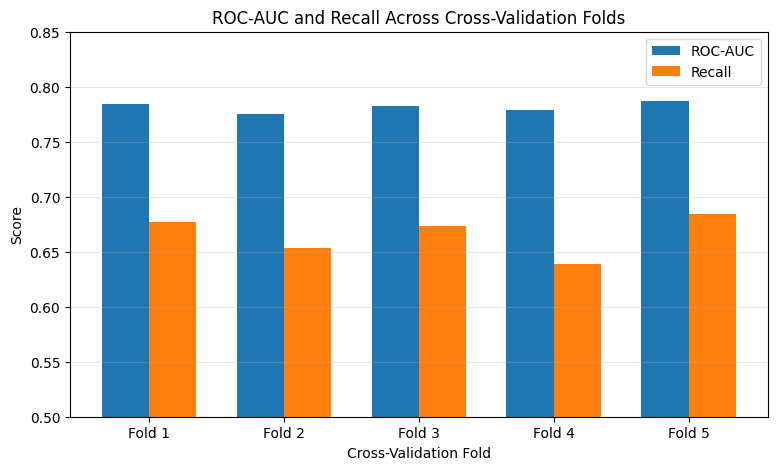

In [44]:

folds = np.arange(1, 6)

roc_auc = [0.78452911, 0.77475876, 0.78219752, 0.77850655, 0.78741006]
recall = [0.677258, 0.653010, 0.673077, 0.639098, 0.684211]

x = np.arange(len(folds))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, roc_auc, width, label="ROC-AUC")
plt.bar(x + width/2, recall, width, label="Recall")

plt.xlabel("Cross-Validation Fold")
plt.ylabel("Score")
plt.title("ROC-AUC and Recall Across Cross-Validation Folds")

plt.xticks(x, [f"Fold {i}" for i in folds])
plt.ylim(0.5, 0.85)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [25]:
# Train final model on the complete training data
rf_pipeline.fit(X_train, y_train)

print("Final model trained successfully!")

Final model trained successfully!


In [26]:
# Probability of booking completion
y_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print(y_test_proba[:10])

[0.33  0.005 0.33  0.005 0.38  0.205 0.575 0.01  0.035 0.035]


In [27]:
# Final predictions using threshold 0.20
y_test_pred = (y_test_proba >= 0.20).astype(int)

print(y_test_pred[:10])

[1 0 1 0 1 1 1 0 0 0]


In [28]:

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_proba)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Not Completed", "Completed"]
))

Precision : 0.3258
Recall    : 0.6818
ROC-AUC   : 0.7902

Classification Report:
               precision    recall  f1-score   support

Not Completed       0.93      0.75      0.83      8504
    Completed       0.33      0.68      0.44      1496

     accuracy                           0.74     10000
    macro avg       0.63      0.72      0.64     10000
 weighted avg       0.84      0.74      0.77     10000



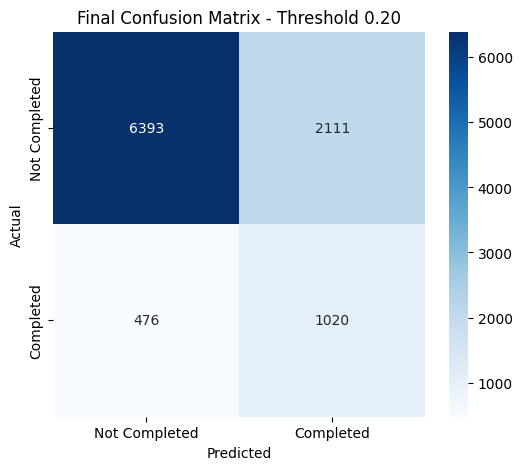

In [29]:

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Completed", "Completed"],
    yticklabels=["Not Completed", "Completed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix - Threshold 0.20")

plt.show()

In [33]:
rf_final_model = rf_pipeline.named_steps["model"]

importances = rf_final_model.feature_importances_

preprocessor_fitted = rf_pipeline.named_steps["preprocessing"]
feature_names = preprocessor_fitted.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

In [35]:
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("onehot__", "", regex=False)
)

feature_importance

,Feature,Importance
10,route,0.189952
6,purchase_lead,0.163322
8,flight_hour,0.117801
7,length_of_stay,0.106784
11,booking_origin,0.103260
9,flight_day,0.075385
15,flight_duration,0.068302
5,num_passengers,0.045871
20,total_extras,0.025061
17,is_early_morning,0.017435


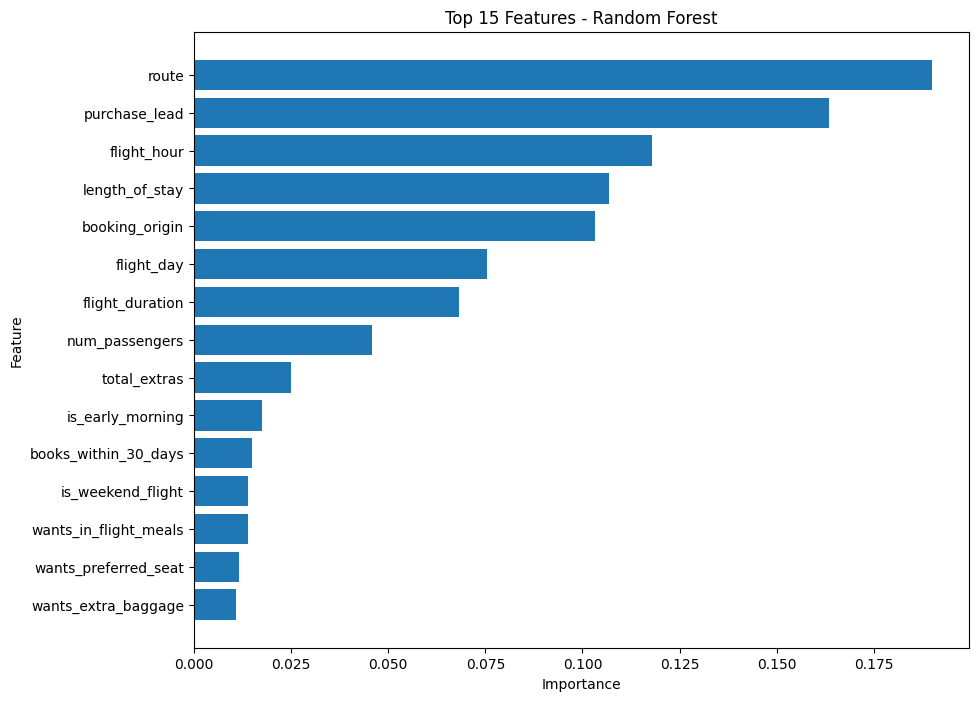

In [36]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.show()

In [37]:

threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

    predictions = (y_test_proba >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)

    threshold_results.append([
        threshold,
        precision,
        recall
    ])

threshold_results_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Precision", "Recall"]
)

threshold_results_df

,Threshold,Precision,Recall
0,0.10,0.259446,0.858289
1,0.15,0.294253,0.770053
2,0.20,0.325775,0.681818
3,0.25,0.352245,0.576872
4,0.30,0.384284,0.477273
5,0.35,0.414017,0.383021
6,0.40,0.442095,0.293449
7,0.45,0.508172,0.228610
8,0.50,0.523596,0.155749


In [38]:
total_customers = len(y_test)

actual_buyers = (y_test == 1).sum()
targeted_customers = (y_test_pred == 1).sum()

buyers_captured = ((y_test == 1) & (y_test_pred == 1)).sum()
non_buyers_targeted = ((y_test == 0) & (y_test_pred == 1)).sum()
buyers_missed = ((y_test == 1) & (y_test_pred == 0)).sum()

print(f"Total customers: {total_customers}")

print(
    f"Customers targeted: {targeted_customers} "
    f"({targeted_customers / total_customers * 100:.2f}%)"
)

print(
    f"Actual buyers captured: {buyers_captured} "
    f"({buyers_captured / actual_buyers * 100:.2f}% of actual buyers)"
)

print(
    f"Non-buyers targeted: {non_buyers_targeted} "
    f"({non_buyers_targeted / targeted_customers * 100:.2f}% of targeted customers)"
)

print(
    f"Actual buyers missed: {buyers_missed} "
    f"({buyers_missed / actual_buyers * 100:.2f}% of actual buyers)"
)

Total customers: 10000
Customers targeted: 3131 (31.31%)
Actual buyers captured: 1020 (68.18% of actual buyers)
Non-buyers targeted: 2111 (67.42% of targeted customers)
Actual buyers missed: 476 (31.82% of actual buyers)
